# Predicting Doctor Visits with Healthcare Analytics
**Author:** Govardhan Sudhakar Mandal  
**Project:** TIRTC DIY Project

**Problem:** Why do some people visit a doctor far more often than others? We explore the dataset, find the key drivers of doctor visits, and build models to predict visits.

> **Colab users:** upload `Healthcare_Analytics_for_Doctor_Visits.csv` using the Files panel on the left (or `from google.colab import files; files.upload()`), then run all cells.

## 1. Import libraries

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error, confusion_matrix

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

## 2. Load the data

In [2]:
df = pd.read_csv("Healthcare_Analytics_for_Doctor_Visits.csv")   # change the path if your file is elsewhere
print("Shape:", df.shape)
df.head()

Shape: (5190, 13)


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


## 3. Understand and clean the data
`Unnamed: 0` is only a record ID, so we drop it. We then check for missing values and convert yes/no columns into 0/1 so models can use them.

In [3]:
df = df.drop(columns=["Unnamed: 0"])
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum(), "(kept: different people can have identical answers)")
df.describe().round(2)

Missing values: 0
Duplicate rows: 1320 (kept: different people can have identical answers)


,visits,age,income,illness,reduced,health
count,5190.0,5190.00,5190.00,5190.00,5190.00,5190.00
mean,0.3,0.41,0.58,1.43,0.86,1.22
std,0.8,0.20,0.37,1.38,2.89,2.12
min,0.0,0.19,0.00,0.00,0.00,0.00
25%,0.0,0.22,0.25,0.00,0.00,0.00
50%,0.0,0.32,0.55,1.00,0.00,0.00
75%,0.0,0.62,0.90,2.00,0.00,2.00
max,9.0,0.72,1.50,5.00,14.00,12.00


In [4]:
for c in ["private", "freepoor", "freerepat", "nchronic", "lchronic"]:
    df[c] = (df[c] == "yes").astype(int)
df["gender"] = (df["gender"] == "female").astype(int)      # 1 = female, 0 = male
df["visited"] = (df["visits"] > 0).astype(int)             # new target: visited at least once
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic,visited
0,1,1,0.19,0.55,1,4,1,1,0,0,0,0,1
1,1,1,0.19,0.45,1,2,1,1,0,0,0,0,1
2,1,0,0.19,0.90,3,0,0,0,0,0,0,0,1
3,1,0,0.19,0.15,1,0,0,0,0,0,0,0,1
4,1,0,0.19,0.45,2,5,1,0,0,0,1,0,1


## 4. Exploratory Data Analysis

### 4.1 How many visits do people make?

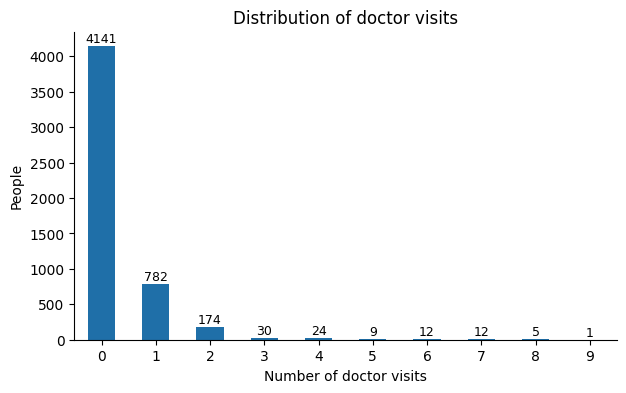

People with 0 visits: 79.8%


In [5]:
vc = df["visits"].value_counts().sort_index()
ax = vc.plot(kind="bar", color="#1F6FA8", figsize=(7, 4))
for i, v in enumerate(vc.values): ax.text(i, v + 50, v, ha="center", fontsize=9)
plt.xlabel("Number of doctor visits"); plt.ylabel("People"); plt.title("Distribution of doctor visits")
plt.xticks(rotation=0); plt.show()
print(f"People with 0 visits: {(df.visits == 0).mean():.1%}")

**Insight:** about 80% of people made no visit, so the data is heavily skewed towards zero. This is *count data*, which suits Poisson regression.

### 4.2 Average visits by group

In [6]:
groups = {"Chronic (long-term)": "lchronic", "Chronic (other)": "nchronic", "Free repat. cover": "freerepat",
          "Free poor cover": "freepoor", "Private insurance": "private", "Female": "gender"}
g = pd.DataFrame([(k, df[df[c] == 1].visits.mean(), df[df[c] == 0].visits.mean()) for k, c in groups.items()],
                 columns=["Group", "Yes", "No"]).set_index("Group")
g.round(2)

,Yes,No
Group,,
Chronic (long-term),0.60,0.26
Chronic (other),0.35,0.27
Free repat. cover,0.47,0.26
Free poor cover,0.16,0.31
Private insurance,0.29,0.31
Female,0.36,0.24


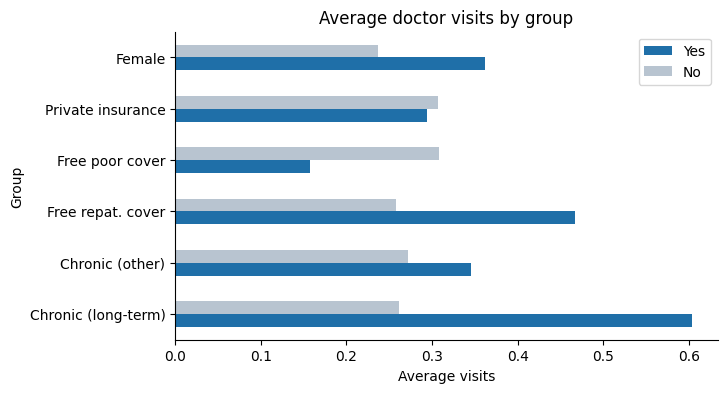

In [7]:
g.plot(kind="barh", figsize=(7, 4), color=["#1F6FA8", "#B8C4D0"])
plt.xlabel("Average visits"); plt.title("Average doctor visits by group"); plt.show()

**Insight:** long-term chronic illness (0.60 vs 0.26) and free repatriation cover (0.47 vs 0.26) go with more visits. Free poor cover goes with fewer visits (0.16 vs 0.31). Private insurance makes almost no difference.

### 4.3 Health impact and correlation

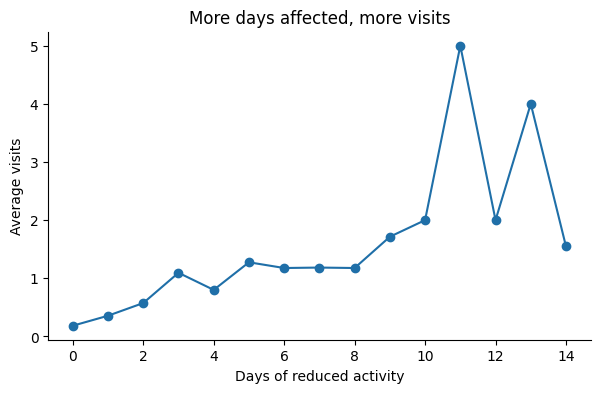

reduced      0.42
illness      0.22
health       0.19
lchronic     0.14
age          0.12
freerepat    0.11
gender       0.08
nchronic     0.05
private     -0.01
freepoor    -0.04
income      -0.08
Name: visits, dtype: float64

In [8]:
r = df.groupby("reduced")["visits"].mean()
plt.figure(figsize=(7, 4)); plt.plot(r.index, r.values, marker="o", color="#1F6FA8")
plt.xlabel("Days of reduced activity"); plt.ylabel("Average visits"); plt.title("More days affected, more visits"); plt.show()
df.corr()["visits"].drop(["visits", "visited"]).sort_values(ascending=False).round(2)

**Insight:** `reduced` (days of reduced activity) has the strongest link with visits, followed by `illness`.

## 5. Prepare data for modelling
We split into 80% training and 20% testing data. `stratify` keeps the same share of visitors in both parts.

In [9]:
X = df.drop(columns=["visits", "visited"])
Xtr, Xte, ytr_c, yte_c, ytr_b, yte_b = train_test_split(
    X, df["visits"], df["visited"], test_size=0.2, random_state=42, stratify=df["visited"])
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
print("Train:", Xtr.shape, " Test:", Xte.shape)

Train: (4152, 11)  Test: (1038, 11)


## 6. Model 1: Poisson Regression (predict the number of visits)

In [10]:
pr = PoissonRegressor(alpha=1e-4, max_iter=1000).fit(Xtr_s, ytr_c)
mae_model = mean_absolute_error(yte_c, pr.predict(Xte_s))
mae_base = mean_absolute_error(yte_c, np.full(len(yte_c), ytr_c.mean()))
print(f"Poisson MAE: {mae_model:.3f}   |   Baseline (always predict the average): {mae_base:.3f}")

effect = pd.Series(np.exp(pr.coef_), index=X.columns).sort_values(ascending=False)
print("\nVisit multiplier for a 1-standard-deviation increase (above 1 = more visits):")
effect.round(2)

Poisson MAE: 0.410   |   Baseline (always predict the average): 0.469

Visit multiplier for a 1-standard-deviation increase (above 1 = more visits):


reduced      1.46
illness      1.29
gender       1.09
age          1.08
nchronic     1.08
private      1.06
lchronic     1.05
health       1.05
freerepat    1.01
income       0.92
freepoor     0.90
dtype: float64

**Insight:** the model beats the simple-average baseline. `reduced` has the largest effect (about 1.46x more expected visits per standard deviation).

## 7. Models 2 and 3: Will a person visit a doctor? (classification)

In [11]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_s, ytr_b)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced", random_state=42).fit(Xtr, ytr_b)

rows = []
for name, m, xt in [("Logistic Regression", lr, Xte_s), ("Random Forest", rf, Xte)]:
    pred, prob = m.predict(xt), m.predict_proba(xt)[:, 1]
    rows.append([name, accuracy_score(yte_b, pred), f1_score(yte_b, pred), roc_auc_score(yte_b, prob)])
res = pd.DataFrame(rows, columns=["Model", "Accuracy", "F1", "ROC-AUC"]).set_index("Model").round(3)
print(f"Majority-class accuracy (always predict 'no visit'): {1 - yte_b.mean():.3f}")
res

Majority-class accuracy (always predict 'no visit'): 0.798


,Accuracy,F1,ROC-AUC
Model,,,
Logistic Regression,0.716,0.459,0.736
Random Forest,0.729,0.456,0.736


**How to read this:** always predicting 'no visit' gets about 80% accuracy but finds nobody who needs care, so accuracy alone is misleading. ROC-AUC (0.5 = guessing, 1.0 = perfect) is the fairer measure, and both models score about 0.74, which is a moderate result.

In [12]:
cm = confusion_matrix(yte_b, rf.predict(Xte))
pd.DataFrame(cm, index=["Actual: no visit", "Actual: visit"], columns=["Pred: no visit", "Pred: visit"])

,Pred: no visit,Pred: visit
Actual: no visit,639,189
Actual: visit,92,118


## 8. Which factors matter most?

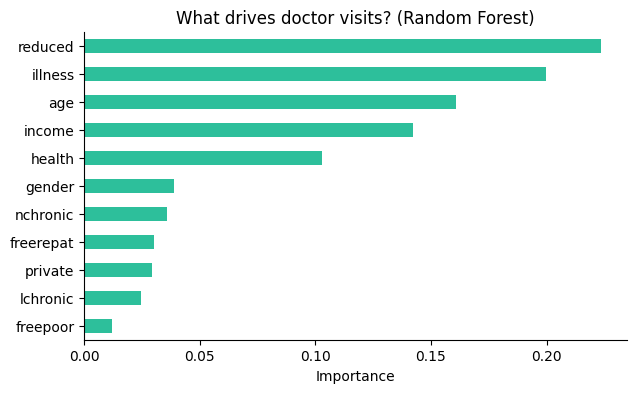

In [13]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind="barh", color="#2DBF9B", figsize=(7, 4))
plt.xlabel("Importance"); plt.title("What drives doctor visits? (Random Forest)"); plt.show()

## 9. Conclusion
- About 80% of people never visit a doctor; visits are heavily skewed towards 0.
- **Days of reduced activity** and **number of illnesses** are the strongest drivers, followed by age and income.
- Long-term chronic illness and free repatriation cover go with more visits; free poor cover goes with fewer; private insurance has little effect.
- Both classifiers reach a ROC-AUC of about 0.74, so the available features explain visits only moderately.

**Limitations:** the data has no information on the type of illness or on access to clinics, and the visit counts are very imbalanced.

**Future work:** try negative binomial / zero-inflated models, tune hyperparameters, and add more features.

**Who benefits:** hospitals (capacity planning), insurers (pricing), health departments (targeting free-care programmes), and doctors (spotting high-need patients).